# Reversal Strategy Backtest -- MOEX

Backtest of a long-only reversal strategy: buy stocks after a sustained 10-day decline when OFI begins recovering, exit after 5 days. Parameters calibrated in notebook 14 EDA. Entry filter: `ret_10d < -10%`, realized volatility 28--65% annualized, spread BBO < 50 bps. Ranking signal: `ofi_vol_roll5` (least negative OFI = bullish). Data: AlgoPack 5-min bars, MOEX top-40 universe.


In [1]:
import os, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
from itertools import product

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = [
    'AFLT','ALRS','AQUA','BANE','BANEP','BSPB','CHMF','ENRU','FEES','FESH',
    'FIVE','GAZP','GMKN','IRAO','LKOH','LSNGP','LSRG','MAGN','MGNT','MOEX',
    'MRKS','MSNG','MTSS','MVID','NLMK','NVTK','OZON','PHOR','PLZL','POLY',
    'POSI','QIWI','RENI','ROSN','RUAL','SBER','SBERP','SELG','SNGS','SNGSP',
    'TATN','TATNP','TCSG','TRMK','TRNFP','VKCO','VTBR','YNDX'
]

BASE_DIR = '/Users/aakhrameshin/Documents/Side projects/ru_trade'
TMP_DIR  = '/tmp/ru_trade_algopack'

COST_RT  = 0.0036   # 0.36% за RT (комиссия + slippage)
TRAIN_END = '2024-12-31'
TEST_START = '2025-01-01'

print('Настройки загружены.')

Настройки загружены.


## 1. Data Loading


In [2]:
def copy_to_tmp(table, ticker):
    src = f'{BASE_DIR}/data/cache/algopack/{table}/{ticker}.parquet'
    dst = f'{TMP_DIR}/{table}/{ticker}.parquet'
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
        with open(src, 'rb') as f:
            data = f.read()
        with open(dst, 'wb') as f:
            f.write(data)
    return dst

def load_table(table):
    frames = []
    for t in TICKERS:
        src = f'{BASE_DIR}/data/cache/algopack/{table}/{t}.parquet'
        if not os.path.exists(src):
            continue
        frames.append(pd.read_parquet(copy_to_tmp(table, t)))
    df = pd.concat(frames, ignore_index=True)
    df['ts'] = pd.to_datetime(df['ts'])
    return df.sort_values(['ticker', 'ts']).reset_index(drop=True)

print('Загрузка...')
ts_raw = load_table('tradestats')
ob_raw = load_table('obstats')
or_raw = load_table('orderstats')
print(f'tradestats: {len(ts_raw):,} | obstats: {len(ob_raw):,} | orderstats: {len(or_raw):,}')

Загрузка...
tradestats: 6,857,289 | obstats: 7,016,134 | orderstats: 7,009,647


## 2. Daily Table and Rolling Metrics


In [3]:
ts_daily = (
    ts_raw.assign(date=ts_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(open=('pr_open','first'), close=('pr_close','last'),
         tfi_median=('disb','median'), intraday_vol=('pr_close','std'),
         vol_total=('vol','sum'), val_total=('val','sum'), n_bars=('pr_close','count'))
    .reset_index()
)
ts_daily['date'] = pd.to_datetime(ts_daily['date'])

ob_daily = (
    ob_raw.assign(date=ob_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(ofi_vol_median=('imbalance_vol','median'),
         spread_bbo_q80=('spread_bbo', lambda x: x.quantile(0.8)))
    .reset_index()
)
ob_daily['date'] = pd.to_datetime(ob_daily['date'])

or_daily = (
    or_raw.assign(date=or_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(cancel_vol_b=('cancel_vol_b','sum'), cancel_vol_s=('cancel_vol_s','sum'),
         put_vol_b=('put_vol_b','sum'), put_vol_s=('put_vol_s','sum'))
    .reset_index()
)
or_daily['date'] = pd.to_datetime(or_daily['date'])
or_daily['cancel_delta'] = (
    or_daily['cancel_vol_s'] / (or_daily['put_vol_s'] + 1) -
    or_daily['cancel_vol_b'] / (or_daily['put_vol_b'] + 1)
)

daily = (
    ts_daily
    .merge(ob_daily, on=['ticker','date'], how='left')
    .merge(or_daily[['ticker','date','cancel_delta']], on=['ticker','date'], how='left')
    .sort_values(['ticker','date'])
    .reset_index(drop=True)
)

# Rolling метрики -- явный цикл чтобы ticker остался колонкой
def add_rolling(df):
    g = df.copy()
    g['ret_1d']  = g['close'].pct_change()
    for n in [5, 10, 15]:
        g[f'ret_{n}d'] = g['close'].pct_change(n)
    log_ret = np.log(g['close'] / g['close'].shift(1))
    for n in [5, 10, 20]:
        g[f'rvol_{n}d'] = log_ret.rolling(n).std() * np.sqrt(252)
    g['ofi_vol_roll5']  = g['ofi_vol_median'].rolling(5).mean()
    g['tfi_roll5']      = g['tfi_median'].rolling(5).mean()
    g['cancel_roll5']   = g['cancel_delta'].rolling(5).mean()
    # next-day open для входа без look-ahead
    g['next_open'] = g['open'].shift(-1)
    return g

frames = []
for ticker, grp in daily.groupby('ticker'):
    frames.append(add_rolling(grp))
daily = pd.concat(frames, ignore_index=True)
daily = daily.dropna(subset=['ret_10d','rvol_10d','ofi_vol_roll5']).reset_index(drop=True)

print(f'Строк: {len(daily):,} | Тикеров: {daily["ticker"].nunique()} | Период: {daily["date"].min().date()} → {daily["date"].max().date()}')

Строк: 42,537 | Тикеров: 48 | Период: 2023-01-17 → 2026-06-13


## 3. Signal Generation

Signal on day T -> entry at open[T+1], exit at close[T+hold_days].


In [4]:
# Базовые параметры (из EDA)
DECLINE_THR  = -0.10   # ret_10d < -10%
RVOL_MIN     =  0.28   # мин. волатильность
RVOL_MAX     =  0.65   # макс. волатильность
SPREAD_MAX   =  50.0   # макс. спред BBO (в базисных пунктах)
HOLD_DAYS    =  5      # дней держим позицию
N_POS        =  3      # макс. одновременных позиций

def build_signals(df, decline_thr=DECLINE_THR, rvol_min=RVOL_MIN,
                  rvol_max=RVOL_MAX, spread_max=SPREAD_MAX):
    """Возвращает строки где условия фильтра выполнены."""
    mask = (
        (df['ret_10d']       < decline_thr) &
        (df['rvol_10d']      >= rvol_min)   &
        (df['rvol_10d']      <= rvol_max)   &
        (df['spread_bbo_q80'] <= spread_max) &
        df['next_open'].notna()              # есть следующий день
    )
    return df[mask].copy()

signals = build_signals(daily)
print(f'Всего сигналов: {len(signals):,}')
print(f'Уникальных тикеров: {signals["ticker"].nunique()}')
print(f'Период: {signals["date"].min().date()} → {signals["date"].max().date()}')
print()
print('Топ тикеров по количеству сигналов:')
print(signals['ticker'].value_counts().head(15).to_string())

Всего сигналов: 1,163
Уникальных тикеров: 48
Период: 2023-01-30 → 2026-06-11

Топ тикеров по количеству сигналов:
ticker
FESH    66
VKCO    60
SELG    53
MVID    51
FEES    50
POSI    46
TRMK    44
VTBR    44
MAGN    43
MGNT    39
QIWI    39
AFLT    30
MSNG    29
MRKS    28
POLY    28


## 4. Trade Simulation

Each day T: take top-N stocks by `ofi_vol_roll5` (least negative OFI). No pyramiding -- skip ticker if already in position.


In [5]:
def run_backtest(df_daily, signals_df, n_pos=N_POS, hold_days=HOLD_DAYS,
                 cost_rt=COST_RT, start_date=None, end_date=None):
    """
    Симулирует сделки.
    Вход: open[T+1], Выход: close[T+hold_days]
    Ранжирование по ofi_vol_roll5 (выбираем наименее отрицательный).
    """
    # Индекс цен: ticker → date → close/open
    price_idx = df_daily.set_index(['ticker','date'])

    sig = signals_df.copy()
    if start_date:
        sig = sig[sig['date'] >= pd.Timestamp(start_date)]
    if end_date:
        sig = sig[sig['date'] <= pd.Timestamp(end_date)]

    trades = []
    open_positions = {}  # ticker → exit_date (чтобы не пирамидить)

    for signal_date, day_signals in sig.groupby('date'):
        # Убираем тикеры где уже открыта позиция
        expired = [t for t, ed in open_positions.items() if ed <= signal_date]
        for t in expired:
            del open_positions[t]

        available = day_signals[~day_signals['ticker'].isin(open_positions)]
        if available.empty:
            continue

        # Ранжируем по OFI (наибольший = наименее отрицательный = самый бычий)
        top = available.nlargest(n_pos, 'ofi_vol_roll5')

        for _, row in top.iterrows():
            ticker = row['ticker']
            entry_price = row['next_open']  # open[T+1]

            # Ищем цену выхода: close через hold_days торговых дней
            ticker_prices = price_idx.loc[ticker] if ticker in price_idx.index.get_level_values(0) else None
            if ticker_prices is None:
                continue
            future_dates = ticker_prices[ticker_prices.index > signal_date].index
            if len(future_dates) < hold_days:
                continue
            exit_date  = future_dates[hold_days - 1]
            exit_price = ticker_prices.loc[exit_date, 'close']

            ret_gross = exit_price / entry_price - 1
            ret_net   = ret_gross - cost_rt

            trades.append({
                'ticker':       ticker,
                'signal_date':  signal_date,
                'entry_price':  entry_price,
                'exit_date':    exit_date,
                'exit_price':   exit_price,
                'ret_gross':    ret_gross,
                'ret_net':      ret_net,
                'ofi_signal':   row['ofi_vol_roll5'],
                'ret_10d_at_entry': row['ret_10d'],
                'rvol_at_entry': row['rvol_10d'],
            })
            open_positions[ticker] = exit_date

    return pd.DataFrame(trades)

trades = run_backtest(daily, signals)
print(f'Всего сделок: {len(trades)}')
if len(trades) > 0:
    print(f'Период: {trades["signal_date"].min().date()} → {trades["signal_date"].max().date()}')
    print(f'Win rate: {(trades["ret_net"] > 0).mean()*100:.1f}%')
    print(f'Avg ret (gross): {trades["ret_gross"].mean()*100:+.2f}%')
    print(f'Avg ret (net):   {trades["ret_net"].mean()*100:+.2f}%')
    print()
    print(trades[['ticker','signal_date','exit_date','ret_gross','ret_net','ofi_signal']].head(10).to_string())

Всего сделок: 364
Период: 2023-01-30 → 2026-06-01
Win rate: 51.4%
Avg ret (gross): +0.24%
Avg ret (net):   -0.12%

  ticker signal_date  exit_date  ret_gross   ret_net    ofi_signal
0   TRMK  2023-01-30 2023-02-06   0.033412  0.029812 -1.320000e-01
1   PLZL  2023-02-15 2023-02-22   0.031866  0.028266 -4.200000e-02
2   TCSG  2023-02-15 2023-02-22  -0.008600 -0.012200 -1.100000e-01
3   ENRU  2023-02-20 2023-02-28   0.035186  0.031586  2.000000e-02
4   TRMK  2023-05-02 2023-05-10   0.003398 -0.000202  1.160000e-01
5   POLY  2023-05-23 2023-05-30   0.100281  0.096681  2.775558e-17
6   MGNT  2023-05-25 2023-06-01   0.081951  0.078351 -3.600000e-02
7   FEES  2023-06-06 2023-06-14   0.026199  0.022599 -1.180000e-01
8   POLY  2023-06-09 2023-06-19   0.050747  0.047147  1.080000e-01
9   POLY  2023-06-19 2023-06-26  -0.016453 -0.020053  1.200000e-02


## 5. Equity Curve and Metrics



=== ВСЕ ДАННЫЕ (2023–2026) (N=364 сделок) ===
Win rate:         51.4%
Avg ret (net):    -0.12%
Avg win:          +4.43%
Avg loss:         -4.93%
Profit Factor:    0.95
Sharpe (ann):     -0.13
Ann return (est): -6.3%
Max Drawdown:     -93.9%
p-value (t-test): 0.7238  


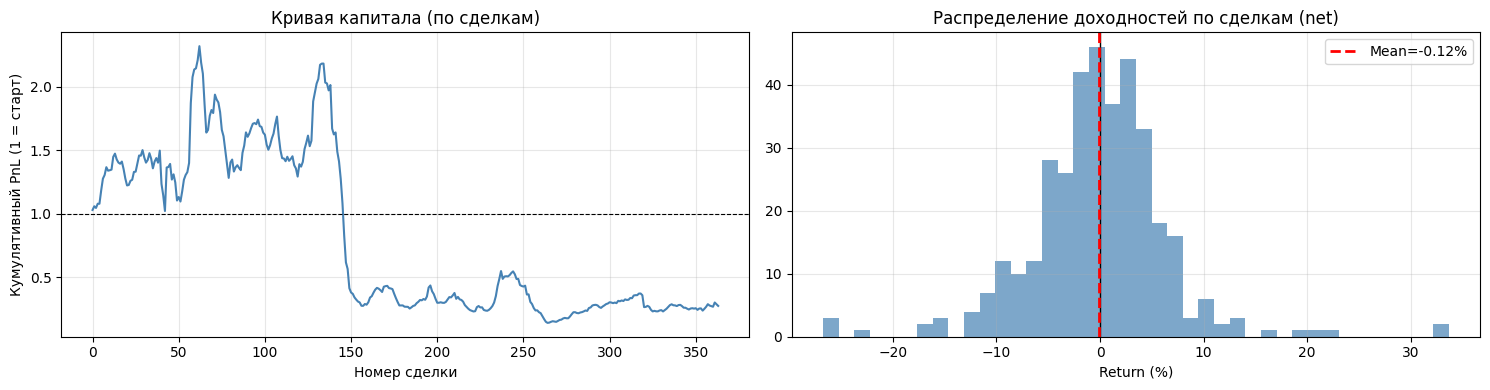

In [7]:
def compute_metrics(trades_df, label=''):
    """Считает Sharpe, DD, Profit Factor по сделкам."""
    if trades_df.empty:
        return {}
    r = trades_df['ret_net']
    n = len(r)
    win_rate = (r > 0).mean()
    avg_win  = r[r > 0].mean() if (r > 0).any() else 0
    avg_loss = r[r < 0].mean() if (r < 0).any() else 0
    pf = -avg_win * (r > 0).sum() / (avg_loss * (r < 0).sum() + 1e-9)

    ann_ret = r.mean() * 252 / 5
    sharpe  = (r.mean() / r.std()) * np.sqrt(252 / 5) if r.std() > 0 else 0

    cum    = (1 + r).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()

    _, p_val = stats.ttest_1samp(r, 0)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

    print(f'\n=== {label} (N={n} сделок) ===')
    print(f'Win rate:         {win_rate*100:.1f}%')
    print(f'Avg ret (net):    {r.mean()*100:+.2f}%')
    print(f'Avg win:          {avg_win*100:+.2f}%')
    print(f'Avg loss:         {avg_loss*100:+.2f}%')
    print(f'Profit Factor:    {pf:.2f}')
    print(f'Sharpe (ann):     {sharpe:.2f}')
    print(f'Ann return (est): {ann_ret*100:+.1f}%')
    print(f'Max Drawdown:     {max_dd*100:.1f}%')
    print(f'p-value (t-test): {p_val:.4f}  {sig}')
    return {'n': n, 'wr': win_rate, 'avg_ret': r.mean(), 'sharpe': sharpe, 'max_dd': max_dd, 'pf': pf, 'p': p_val}

def plot_equity(trades_df, title='Кривая капитала'):
    if trades_df.empty:
        return
    r = trades_df.sort_values('signal_date')['ret_net']
    cum = (1 + r).cumprod()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(range(len(cum)), cum.values, color='steelblue', lw=1.5)
    axes[0].axhline(1, color='black', lw=0.8, linestyle='--')
    axes[0].set_title(f'{title} (по сделкам)')
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Кумулятивный PnL (1 = старт)')

    r_pct = trades_df['ret_net'] * 100
    axes[1].hist(r_pct, bins=40, color='steelblue', alpha=0.7, edgecolor='none')
    axes[1].axvline(0, color='black', lw=1)
    axes[1].axvline(r_pct.mean(), color='red', lw=2, linestyle='--', label=f'Mean={r_pct.mean():+.2f}%')
    axes[1].set_title('Распределение доходностей по сделкам (net)')
    axes[1].set_xlabel('Return (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

m_all = compute_metrics(trades, 'ВСЕ ДАННЫЕ (2023–2026)')
plot_equity(trades)

## 6. Walk-Forward -- IS vs OOS



=== IN-SAMPLE  (2023–2024, до 2024-12-31) (N=238 сделок) ===
Win rate:         50.8%
Avg ret (net):    +0.02%
Avg win:          +5.03%
Avg loss:         -5.17%
Profit Factor:    1.01
Sharpe (ann):     0.02
Ann return (est): +0.8%
Max Drawdown:     -90.0%
p-value (t-test): 0.9737  

=== OUT-OF-SAMPLE (2025–2026, с 2025-01-01) (N=126 сделок) ===
Win rate:         52.4%
Avg ret (net):    -0.39%
Avg win:          +3.31%
Avg loss:         -4.46%
Profit Factor:    0.82
Sharpe (ann):     -0.51
Ann return (est): -19.7%
Max Drawdown:     -74.0%
p-value (t-test): 0.4223  

WF efficiency (OOS Sharpe / IS Sharpe): -33.53
(>0.5 = хорошо, >1.0 = OOS лучше IS)


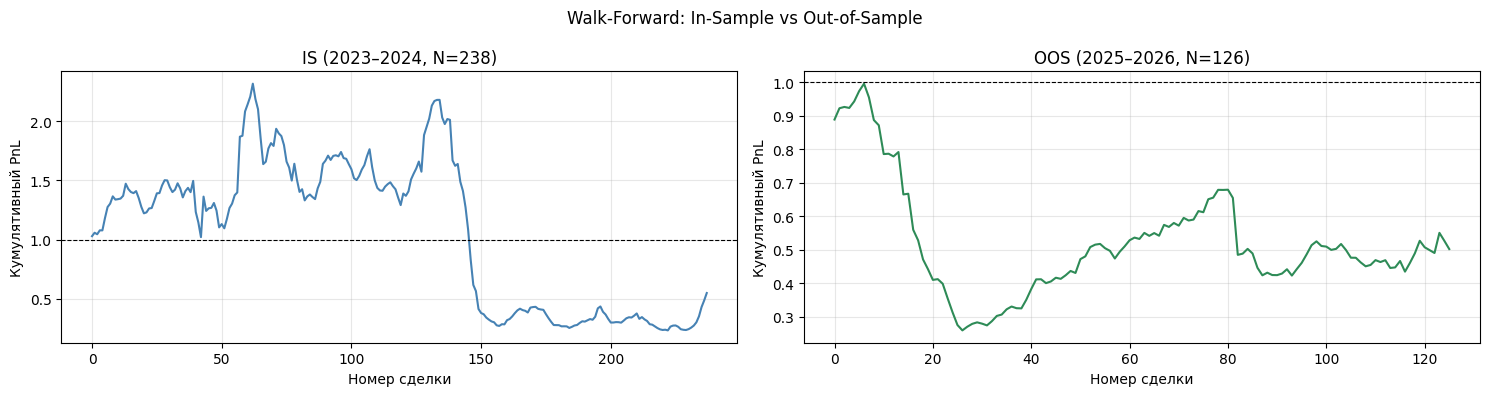

In [8]:
trades_is  = trades[trades['signal_date'] <= TRAIN_END].copy()
trades_oos = trades[trades['signal_date'] >= TEST_START].copy()

m_is  = compute_metrics(trades_is,  f'IN-SAMPLE  (2023–2024, до {TRAIN_END})')
m_oos = compute_metrics(trades_oos, f'OUT-OF-SAMPLE (2025–2026, с {TEST_START})')

if m_is and m_oos:
    print(f'\nWF efficiency (OOS Sharpe / IS Sharpe): {m_oos["sharpe"]/m_is["sharpe"]:.2f}')
    print('(>0.5 = хорошо, >1.0 = OOS лучше IS)')

# Сравнительная визуализация IS vs OOS
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, tdf, label, color in zip(
    axes,
    [trades_is, trades_oos],
    [f'IS (2023–2024, N={len(trades_is)})', f'OOS (2025–2026, N={len(trades_oos)})'],
    ['steelblue', 'seagreen']
):
    if tdf.empty:
        continue
    r = tdf.sort_values('signal_date')['ret_net']
    cum = (1 + r).cumprod()
    ax.plot(range(len(cum)), cum.values, color=color, lw=1.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Номер сделки')
    ax.set_ylabel('Кумулятивный PnL')

plt.suptitle('Walk-Forward: In-Sample vs Out-of-Sample', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Grid Search (IS period only)

Sweep decline threshold, N_pos, hold_days on 2023--2024 data only to avoid look-ahead.


In [9]:
grid_results = []

for decline_thr, rvol_min, rvol_max, hold, n_pos in product(
    [-0.07, -0.10, -0.12, -0.15],   # порог падения
    [0.25, 0.28],                    # мин. rvol
    [0.60, 0.70],                    # макс. rvol
    [3, 5, 7],                       # hold days
    [1, 3, 5],                       # N позиций
):
    sig = build_signals(daily, decline_thr=decline_thr,
                        rvol_min=rvol_min, rvol_max=rvol_max)
    t = run_backtest(daily, sig, n_pos=n_pos, hold_days=hold,
                     end_date=TRAIN_END)
    if len(t) < 20:
        continue
    r = t['ret_net']
    sharpe = (r.mean() / r.std()) * np.sqrt(252 / hold) if r.std() > 0 else 0
    _, p = stats.ttest_1samp(r, 0)
    grid_results.append({
        'decline_thr': decline_thr, 'rvol_min': rvol_min, 'rvol_max': rvol_max,
        'hold': hold, 'n_pos': n_pos,
        'n_trades': len(t), 'wr': (r>0).mean(), 'avg_ret': r.mean(),
        'sharpe': sharpe, 'p': p
    })

grid_df = pd.DataFrame(grid_results).sort_values('sharpe', ascending=False)
print(f'Конфигураций протестировано: {len(grid_df)}')
print('\nТоп-15 по Sharpe (IS 2023–2024):')
print(grid_df.head(15).to_string(index=False))

Конфигураций протестировано: 144

Топ-15 по Sharpe (IS 2023–2024):
 decline_thr  rvol_min  rvol_max  hold  n_pos  n_trades       wr  avg_ret   sharpe        p
       -0.15      0.25       0.6     5      5        79 0.582278 0.016894 1.853263 0.022943
       -0.15      0.28       0.6     5      5        78 0.602564 0.019593 1.827378 0.025795
       -0.15      0.28       0.7     5      5        91 0.582418 0.019971 1.685417 0.025931
       -0.15      0.25       0.7     5      5        91 0.560440 0.016958 1.593595 0.034950
       -0.15      0.28       0.6     5      3        72 0.597222 0.016861 1.534561 0.070822
       -0.15      0.25       0.6     5      3        73 0.575342 0.013978 1.508991 0.073523
       -0.15      0.28       0.7     5      3        85 0.576471 0.017370 1.434958 0.065884
       -0.15      0.25       0.7     5      3        86 0.558140 0.014917 1.380736 0.074834
       -0.15      0.25       0.7     7      3        80 0.562500 0.016267 1.159142 0.087905
       -0.15 

## 8. OOS Validation of Best IS Configuration


In [10]:
# Берём лучшую конфигурацию из IS
best = grid_df.iloc[0]
print('Лучшая IS конфигурация:')
print(f'  decline_thr = {best.decline_thr}')
print(f'  rvol_min    = {best.rvol_min}')
print(f'  rvol_max    = {best.rvol_max}')
print(f'  hold_days   = {int(best.hold)}')
print(f'  n_pos       = {int(best.n_pos)}')
print(f'  IS Sharpe   = {best.sharpe:.2f}, p = {best.p:.4f}')

# Запускаем на OOS
sig_best = build_signals(daily, decline_thr=best.decline_thr,
                         rvol_min=best.rvol_min, rvol_max=best.rvol_max)

trades_best_is  = run_backtest(daily, sig_best, n_pos=int(best.n_pos),
                               hold_days=int(best.hold), end_date=TRAIN_END)
trades_best_oos = run_backtest(daily, sig_best, n_pos=int(best.n_pos),
                               hold_days=int(best.hold), start_date=TEST_START)

m_best_is  = compute_metrics(trades_best_is,  'Лучшая конфиг -- IS  (2023–2024)')
m_best_oos = compute_metrics(trades_best_oos, 'Лучшая конфиг -- OOS (2025–2026)')

if m_best_is and m_best_oos and m_best_is['sharpe'] != 0:
    wf_eff = m_best_oos['sharpe'] / m_best_is['sharpe']
    print(f'\nWF efficiency: {wf_eff:.2f}')
    print('(>0.5 = приемлемо, <0.3 = overfit)')

Лучшая IS конфигурация:
  decline_thr = -0.15
  rvol_min    = 0.25
  rvol_max    = 0.6
  hold_days   = 5
  n_pos       = 5
  IS Sharpe   = 1.85, p = 0.0229

=== Лучшая конфиг — IS  (2023–2024) (N=79 сделок) ===
Win rate:         58.2%
Avg ret (net):    +1.69%
Avg win:          +5.95%
Avg loss:         -4.25%
Profit Factor:    1.95
Sharpe (ann):     1.85
Ann return (est): +85.1%
Max Drawdown:     -37.6%
p-value (t-test): 0.0229  *

=== Лучшая конфиг — OOS (2025–2026) (N=29 сделок) ===
Win rate:         51.7%
Avg ret (net):    +0.77%
Avg win:          +5.21%
Avg loss:         -3.99%
Profit Factor:    1.40
Sharpe (ann):     0.84
Ann return (est): +38.7%
Max Drawdown:     -35.8%
p-value (t-test): 0.5310  

WF efficiency: 0.45
(>0.5 = приемлемо, <0.3 = overfit)


## 9. OFI Ranking vs Random Selection

Compare OFI-ranked entry vs random stock selection among signal candidates -- tests whether OFI adds value beyond the decline filter alone.


Запуск случайного бэктеста (20 runs)...
OFI-стратегия avg ret/сделку: -0.125%
Случайный выбор avg ret/сделку: +1.473% (±0.102%)
OFI лучше случайного в 0% запусков


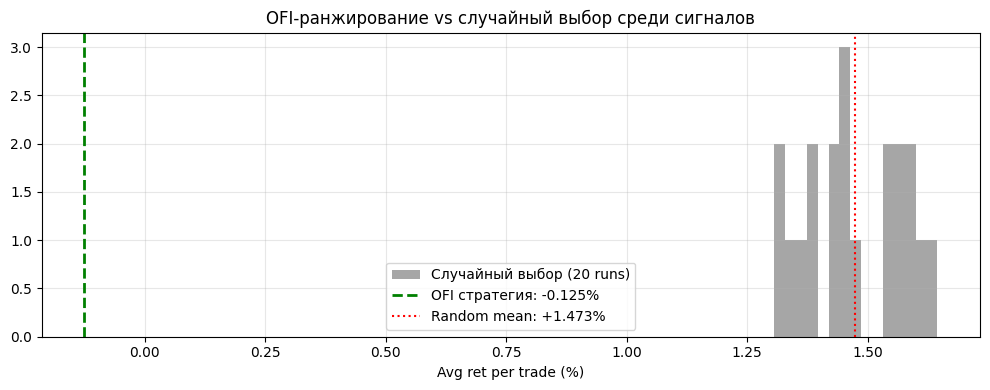

In [11]:
np.random.seed(42)

def run_backtest_random(df_daily, signals_df, n_pos=N_POS, hold_days=HOLD_DAYS,
                        cost_rt=COST_RT, start_date=None, end_date=None, n_runs=20):
    """Запускает бэктест n_runs раз со случайным выбором (вместо OFI ранжирования)."""
    price_idx = df_daily.set_index(['ticker','date'])
    sig = signals_df.copy()
    if start_date:
        sig = sig[sig['date'] >= pd.Timestamp(start_date)]
    if end_date:
        sig = sig[sig['date'] <= pd.Timestamp(end_date)]

    all_avg_rets = []
    for _ in range(n_runs):
        trades_r = []
        open_pos = {}
        for signal_date, day_signals in sig.groupby('date'):
            expired = [t for t, ed in open_pos.items() if ed <= signal_date]
            for t in expired:
                del open_pos[t]
            available = day_signals[~day_signals['ticker'].isin(open_pos)]
            if available.empty:
                continue
            top = available.sample(min(n_pos, len(available)))
            for _, row in top.iterrows():
                ticker = row['ticker']
                entry_price = row['next_open']
                ticker_prices = price_idx.loc[ticker] if ticker in price_idx.index.get_level_values(0) else None
                if ticker_prices is None:
                    continue
                future_dates = ticker_prices[ticker_prices.index > signal_date].index
                if len(future_dates) < hold_days:
                    continue
                exit_date  = future_dates[hold_days - 1]
                exit_price = ticker_prices.loc[exit_date, 'close']
                trades_r.append(exit_price / entry_price - 1 - cost_rt)
                open_pos[ticker] = exit_date
        all_avg_rets.append(np.mean(trades_r) if trades_r else 0)
    return all_avg_rets

print('Запуск случайного бэктеста (20 runs)...')
random_rets = run_backtest_random(daily, sig_best, n_pos=int(best.n_pos),
                                   hold_days=int(best.hold))

ofi_avg_ret = trades['ret_net'].mean()
random_mean = np.mean(random_rets)

print(f'OFI-стратегия avg ret/сделку: {ofi_avg_ret*100:+.3f}%')
print(f'Случайный выбор avg ret/сделку: {random_mean*100:+.3f}% (±{np.std(random_rets)*100:.3f}%)')

percentile = np.mean(np.array(random_rets) < ofi_avg_ret) * 100
print(f'OFI лучше случайного в {percentile:.0f}% запусков')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.array(random_rets)*100, bins=15, color='gray', alpha=0.7, label='Случайный выбор (20 runs)')
ax.axvline(ofi_avg_ret*100, color='green', lw=2, linestyle='--',
           label=f'OFI стратегия: {ofi_avg_ret*100:+.3f}%')
ax.axvline(random_mean*100, color='red', lw=1.5, linestyle=':',
           label=f'Random mean: {random_mean*100:+.3f}%')
ax.set_title('OFI-ранжирование vs случайный выбор среди сигналов')
ax.set_xlabel('Avg ret per trade (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Alpha Test vs IMOEX

Subtract market beta from trade returns to estimate CAPM alpha.


In [12]:
# Загружаем IMOEX дневные данные через data_cache
import sys
sys.path.insert(0, BASE_DIR)
try:
    from data_cache import get_index
    imoex = get_index('IMOEX', interval=24)
    imoex['date'] = pd.to_datetime(imoex['begin'])
    imoex = imoex[['date','close']].rename(columns={'close':'imoex_close'}).sort_values('date')
    imoex['imoex_ret'] = imoex['imoex_close'].pct_change()
    print(f'IMOEX: {len(imoex)} дней, {imoex["date"].min().date()} → {imoex["date"].max().date()}')
    has_imoex = True
except Exception as e:
    print(f'IMOEX не загружен: {e}')
    has_imoex = False

if has_imoex and not trades.empty:
    # Для каждой сделки считаем IMOEX return за тот же период
    imoex_idx = imoex.set_index('date')['imoex_close']

    def get_imoex_ret(signal_date, hold_days):
        future = imoex_idx[imoex_idx.index > signal_date]
        if len(future) < hold_days:
            return np.nan
        entry = imoex_idx[imoex_idx.index <= signal_date].iloc[-1] if (imoex_idx.index <= signal_date).any() else np.nan
        exit_val = future.iloc[hold_days - 1]
        return exit_val / entry - 1 if not np.isnan(entry) else np.nan

    hold = int(best.hold)
    trades_all = run_backtest(daily, sig_best, n_pos=int(best.n_pos), hold_days=hold)
    trades_all['imoex_ret'] = trades_all['signal_date'].apply(lambda d: get_imoex_ret(d, hold))
    trades_all = trades_all.dropna(subset=['imoex_ret'])

    # OLS: alpha
    from numpy.linalg import lstsq
    X = np.column_stack([np.ones(len(trades_all)), trades_all['imoex_ret']])
    y = trades_all['ret_net'].values
    coeffs, _, _, _ = lstsq(X, y, rcond=None)
    alpha, beta = coeffs
    residuals = y - X @ coeffs
    t_alpha = alpha / (residuals.std() / np.sqrt(len(residuals)))
    p_alpha = 2 * stats.t.sf(abs(t_alpha), df=len(residuals)-2)

    sig_a = '***' if p_alpha < 0.001 else '**' if p_alpha < 0.01 else '*' if p_alpha < 0.05 else ''

    print(f'\nAlpha vs IMOEX:')
    print(f'  Alpha per trade: {alpha*100:+.3f}%')
    print(f'  Beta:            {beta:.3f}')
    print(f'  t-stat alpha:    {t_alpha:.2f}')
    print(f'  p-value alpha:   {p_alpha:.4f}  {sig_a}')

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(trades_all['imoex_ret']*100, trades_all['ret_net']*100, alpha=0.3, s=20)
    x_line = np.linspace(trades_all['imoex_ret'].min(), trades_all['imoex_ret'].max(), 100)
    ax.plot(x_line*100, (alpha + beta*x_line)*100, color='red', lw=2,
            label=f'α={alpha*100:+.3f}%, β={beta:.2f}')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel('IMOEX return за период сделки (%)')
    ax.set_ylabel('Стратегия return (%)')
    ax.set_title('Alpha-тест: стратегия vs IMOEX')
    ax.legend()
    plt.tight_layout()
    plt.show()

IMOEX не загружен: 'begin'


## 11. Per-Ticker Analysis


Результаты по тикерам (avg ret net, сортировка по доходности):
         n  avg_ret_pct      wr_pct  total_pct
ticker                                        
OZON     9     5.731145   66.666667  51.580306
FIVE     1     5.397655  100.000000   5.397655
NVTK     4     3.548371  100.000000  14.193484
PHOR     1     3.187443  100.000000   3.187443
ENRU     1     3.158593  100.000000   3.158593
ROSN     7     2.855786   85.714286  19.990503
TATN     6     2.712840   83.333333  16.277041
LSRG     7     2.132497   71.428571  14.927481
GAZP     6     2.075889   50.000000  12.455334
SBERP    1     1.840911  100.000000   1.840911
LSNGP    5     1.731086  100.000000   8.655430
RENI     4     1.678841   75.000000   6.715362
PLZL     5     1.488549   60.000000   7.442747
LKOH     3     1.235416   66.666667   3.706248
RUAL    10     1.219655   70.000000  12.196549
CHMF     6     1.173635   66.666667   7.041807
BSPB     3     0.827047  100.000000   2.481141
MSNG     9     0.676583   55.555556   6.0892

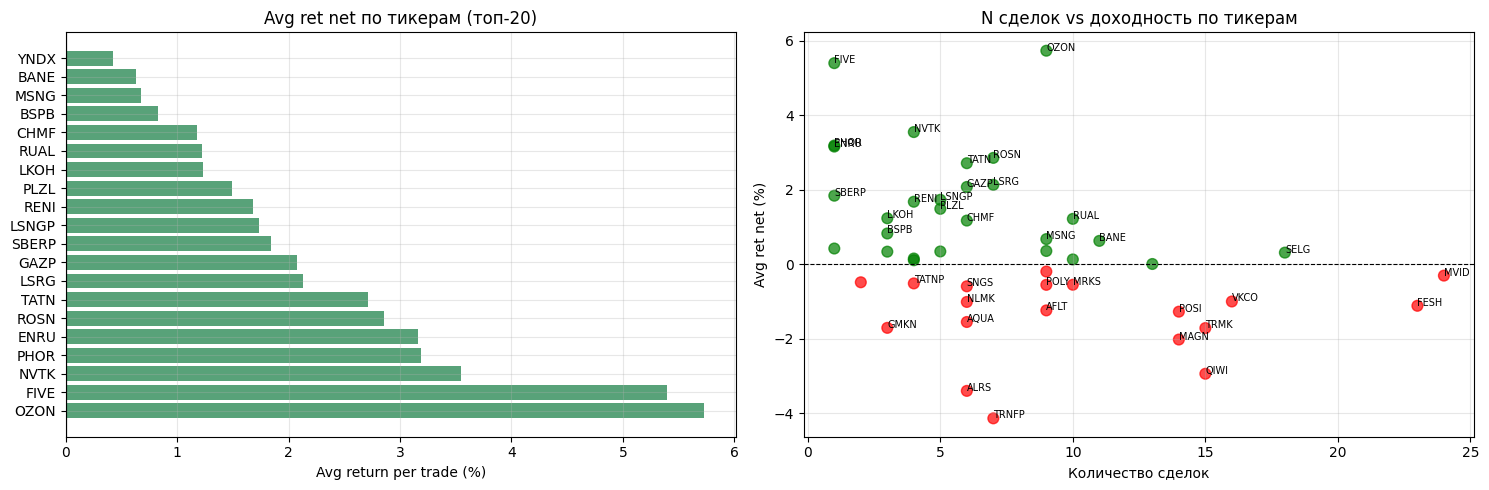

In [13]:
if not trades.empty:
    by_ticker = (
        trades.groupby('ticker')
        .agg(
            n       = ('ret_net', 'count'),
            avg_ret = ('ret_net', 'mean'),
            wr      = ('ret_net', lambda x: (x>0).mean()),
            total   = ('ret_net', 'sum'),
        )
        .sort_values('avg_ret', ascending=False)
    )
    by_ticker['avg_ret_pct'] = by_ticker['avg_ret'] * 100
    by_ticker['total_pct']   = by_ticker['total'] * 100
    by_ticker['wr_pct']      = by_ticker['wr'] * 100

    print('Результаты по тикерам (avg ret net, сортировка по доходности):')
    print(by_ticker[['n','avg_ret_pct','wr_pct','total_pct']].to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    top20 = by_ticker.head(20)
    colors = ['seagreen' if x > 0 else 'tomato' for x in top20['avg_ret_pct']]
    axes[0].barh(top20.index, top20['avg_ret_pct'], color=colors, alpha=0.8)
    axes[0].axvline(0, color='black', lw=0.8)
    axes[0].set_title('Avg ret net по тикерам (топ-20)')
    axes[0].set_xlabel('Avg return per trade (%)')

    axes[1].scatter(by_ticker['n'], by_ticker['avg_ret_pct'],
                    c=['green' if x > 0 else 'red' for x in by_ticker['avg_ret_pct']],
                    alpha=0.7, s=60)
    for t, row in by_ticker.iterrows():
        if abs(row['avg_ret_pct']) > 0.5 or row['n'] > 15:
            axes[1].annotate(t, (row['n'], row['avg_ret_pct']), fontsize=7)
    axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[1].set_xlabel('Количество сделок')
    axes[1].set_ylabel('Avg ret net (%)')
    axes[1].set_title('N сделок vs доходность по тикерам')

    plt.tight_layout()
    plt.show()

## 12. Summary Table


In [14]:
print('=' * 65)
print('ИТОГИ БЭКТЕСТА')
print('=' * 65)

if not trades.empty:
    r = trades['ret_net']
    r_is  = trades_is['ret_net']  if not trades_is.empty  else pd.Series(dtype=float)
    r_oos = trades_oos['ret_net'] if not trades_oos.empty else pd.Series(dtype=float)

    def safe_sharpe(r, hold=5):
        return (r.mean() / r.std()) * np.sqrt(252 / hold) if len(r) > 1 and r.std() > 0 else 0

    sh_is  = safe_sharpe(r_is)
    sh_oos = safe_sharpe(r_oos)
    wf_str = f'{sh_oos/sh_is:.2f}' if sh_is != 0 else 'N/A'

    max_dd = ((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min()

    print(f"""
БАЗОВАЯ КОНФИГУРАЦИЯ:
  decline_thr = {DECLINE_THR*100:.0f}%  |  rvol [{RVOL_MIN*100:.0f}%–{RVOL_MAX*100:.0f}%]  |  hold = {HOLD_DAYS}д  |  N_pos = {N_POS}
  Издержки: {COST_RT*100:.2f}% RT

ПОЛНЫЙ ПЕРИОД (2023–2026):
  Сделок:       {len(trades)}
  Win rate:     {(r>0).mean()*100:.1f}%
  Avg ret net:  {r.mean()*100:+.3f}%
  Sharpe:       {safe_sharpe(r):.2f}
  Max DD:       {max_dd*100:.1f}%

WALK-FORWARD:
  IS  Sharpe: {sh_is:.2f}  (N={len(r_is)})
  OOS Sharpe: {sh_oos:.2f}  (N={len(r_oos)})
  WF efficiency: {wf_str}

ЛУЧШАЯ КОНФИГУРАЦИЯ (из грид-поиска IS):
  decline_thr = {best.decline_thr*100:.0f}%  |  rvol [{best.rvol_min*100:.0f}%–{best.rvol_max*100:.0f}%]
  hold = {int(best.hold)}д  |  N_pos = {int(best.n_pos)}
  IS  Sharpe: {m_best_is.get('sharpe', 0):.2f}
  OOS Sharpe: {m_best_oos.get('sharpe', 0):.2f}
""")

print('\nСледующий шаг:')
print('  Если OOS Sharpe > 0.5 → можно пробовать paper trading')
print('  Если OOS Sharpe < 0.3 → изучить ML-фильтр (ноутбук 16)')

ИТОГИ БЭКТЕСТА

БАЗОВАЯ КОНФИГУРАЦИЯ:
  decline_thr = -10%  |  rvol [28%–65%]  |  hold = 5д  |  N_pos = 3
  Издержки: 0.36% RT

ПОЛНЫЙ ПЕРИОД (2023–2026):
  Сделок:       364
  Win rate:     51.4%
  Avg ret net:  -0.125%
  Sharpe:       -0.13
  Max DD:       -93.9%

WALK-FORWARD:
  IS  Sharpe: 0.02  (N=238)
  OOS Sharpe: -0.51  (N=126)
  WF efficiency: -33.53

ЛУЧШАЯ КОНФИГУРАЦИЯ (из грид-поиска IS):
  decline_thr = -15%  |  rvol [25%–60%]
  hold = 5д  |  N_pos = 5
  IS  Sharpe: 1.85
  OOS Sharpe: 0.84


Следующий шаг:
  Если OOS Sharpe > 0.5 → можно пробовать paper trading
  Если OOS Sharpe < 0.3 → изучить ML-фильтр (ноутбук 16)


---

## Fixes 1 and 2 -- Ticker Filter and Equal Weight

Applied to best IS configuration (decline=-15%, hold=5d, N_pos=5).

Fix 1: exclude tickers with systematically negative IS performance (avg_ret < -0.5%, N >= 5 trades). Threshold determined on IS data only.

Fix 2: equal-weight entry (replace OFI ranking with equal allocation among signal candidates).


In [15]:
# ── Фикс 1: тикерный фильтр ──────────────────────────────────────────────────
# Плохие тикеры определяем ТОЛЬКО по IS-данным (trades_best_is, 2023-2024)
by_ticker_is = (
    trades_best_is.groupby('ticker')
    .agg(n=('ret_net', 'count'), avg_ret=('ret_net', 'mean'))
)
BAD_TICKERS = by_ticker_is[
    (by_ticker_is['avg_ret'] < -0.005) & (by_ticker_is['n'] >= 5)
].index.tolist()

print('IS-статистика по тикерам (лучшая конфиг):')
print(by_ticker_is.sort_values('avg_ret').to_string())
print()
print(f'Плохие тикеры (avg_ret < -0.5%, N≥5): {BAD_TICKERS}')
print(f'Исключаем {len(BAD_TICKERS)} из {daily["ticker"].nunique()} тикеров')

sig_filtered = sig_best[~sig_best['ticker'].isin(BAD_TICKERS)]
print(f'\nСигналов до фильтра:    {len(sig_best)}')
print(f'Сигналов после фильтра: {len(sig_filtered)}')

IS-статистика по тикерам (лучшая конфиг):
        n   avg_ret
ticker             
POSI    2 -0.047246
TRNFP   3 -0.033389
AFLT    1 -0.033360
QIWI    5 -0.025864
VTBR    1 -0.020118
SNGS    2 -0.013546
MRKS    3 -0.012220
MGNT    3 -0.006463
POLY    3 -0.006278
FESH    4  0.001182
BSPB    1  0.003398
GAZP    2  0.006600
MVID    6  0.008682
TRMK    5  0.008913
LSNGP   1  0.012668
FEES    3  0.016165
MAGN    3  0.024827
BANEP   2  0.028993
SELG    5  0.029209
MSNG    3  0.036317
AQUA    2  0.037275
MTSS    1  0.040760
LSRG    2  0.041048
VKCO    6  0.041062
BANE    2  0.045575
GMKN    2  0.051413
NLMK    2  0.068837
ALRS    1  0.085878
OZON    2  0.124850
RUAL    1  0.136454

Плохие тикеры (avg_ret < -0.5%, N≥5): ['QIWI']
Исключаем 1 из 48 тикеров

Сигналов до фильтра:    248
Сигналов после фильтра: 231


Запуск равновесных бэктестов (30 runs × 4)...

──────────────────────────────────────────────────────────────────────────────────────────
Вариант                                               Метрики
──────────────────────────────────────────────────────────────────────────────────────────
IS (2023–2024):
A: все тикеры     + OFI-ранжирование                  N= 79  avg=+1.689%  Sharpe=+1.85  p=0.023 *
B: фильтр тикеров + OFI-ранжирование                  N= 74  avg=+1.978%  Sharpe=+2.25  p=0.008 *
C: все тикеры     + равный вес (30 runs)              N=rnd  avg=+1.693%  ±0.114%
D: фильтр тикеров + равный вес (30 runs)              N=rnd  avg=+2.011%  ±0.118%

OOS (2025–2026):
A: все тикеры     + OFI-ранжирование                  N= 29  avg=+0.769%  Sharpe=+0.84  p=0.531  
B: фильтр тикеров + OFI-ранжирование                  N= 27  avg=+0.607%  Sharpe=+0.68  p=0.621  
C: все тикеры     + равный вес (30 runs)              N=rnd  avg=+0.856%  ±0.156%
D: фильтр тикеров + равный вес (30 ru

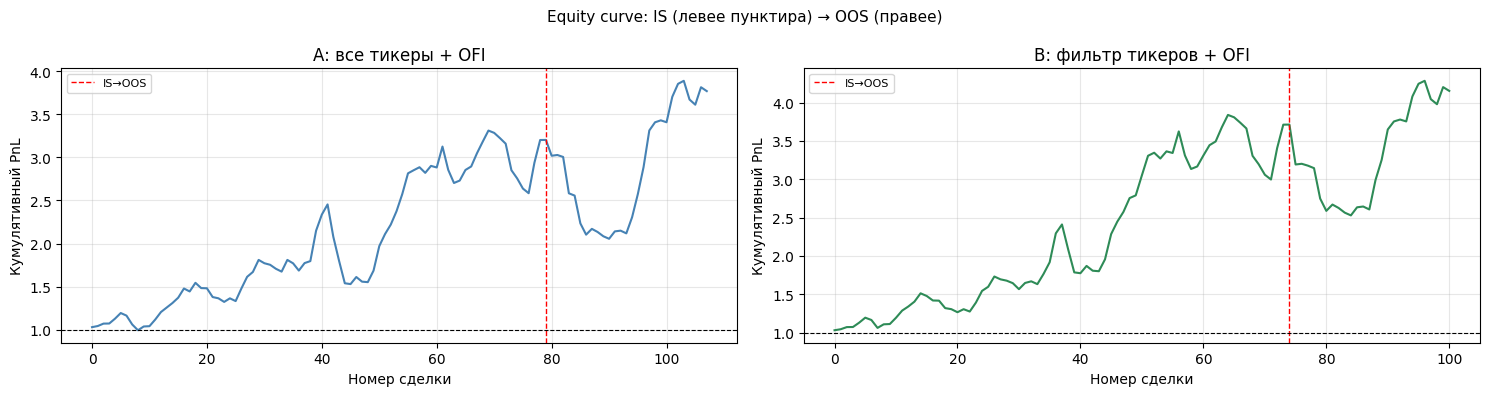


Вывод:
  Вариант A: OOS Sharpe=+0.84  WF=0.45  → paper trading
  Вариант B: OOS Sharpe=+0.68  WF=0.30  → paper trading


In [16]:
# ── Сравнение 4 вариантов ─────────────────────────────────────────────────────
N_RUNS      = 30
n_pos_best  = int(best.n_pos)
hold_best   = int(best.hold)

def fmt_trades(t, label, hold=5):
    if t.empty:
        print(f'{label:<52s}  нет сделок')
        return {}
    r = t['ret_net']
    sh = (r.mean() / r.std()) * np.sqrt(252 / hold) if r.std() > 0 else 0
    _, p = stats.ttest_1samp(r, 0)
    sig = ' *' if p < 0.05 else '  '
    print(f'{label:<52s}  N={len(r):3d}  avg={r.mean()*100:+.3f}%  Sharpe={sh:+.2f}  p={p:.3f}{sig}')
    return {'n': len(r), 'avg_ret': r.mean(), 'sharpe': sh, 'p': p}

def fmt_random(runs, label):
    avg = np.mean(runs)
    std = np.std(runs)
    print(f'{label:<52s}  N=rnd  avg={avg*100:+.3f}%  ±{std*100:.3f}%')
    return {'avg_ret': avg}

# Вариант A: все тикеры + OFI (уже посчитан в ячейке 8)
t_A_is  = trades_best_is
t_A_oos = trades_best_oos

# Вариант B: фильтр тикеров + OFI
t_B_is  = run_backtest(daily, sig_filtered, n_pos=n_pos_best,
                        hold_days=hold_best, end_date=TRAIN_END)
t_B_oos = run_backtest(daily, sig_filtered, n_pos=n_pos_best,
                        hold_days=hold_best, start_date=TEST_START)

# Варианты C и D: равный вес (30 случайных запусков)
print('Запуск равновесных бэктестов (30 runs × 4)...')
r_C_is  = run_backtest_random(daily, sig_best,     n_pos=n_pos_best, hold_days=hold_best,
                               n_runs=N_RUNS, end_date=TRAIN_END)
r_C_oos = run_backtest_random(daily, sig_best,     n_pos=n_pos_best, hold_days=hold_best,
                               n_runs=N_RUNS, start_date=TEST_START)
r_D_is  = run_backtest_random(daily, sig_filtered, n_pos=n_pos_best, hold_days=hold_best,
                               n_runs=N_RUNS, end_date=TRAIN_END)
r_D_oos = run_backtest_random(daily, sig_filtered, n_pos=n_pos_best, hold_days=hold_best,
                               n_runs=N_RUNS, start_date=TEST_START)

SEP = '─' * 90
print()
print(SEP)
print(f'{"Вариант":<52s}  Метрики')
print(SEP)
print('IS (2023–2024):')
m_A_is = fmt_trades(t_A_is, 'A: все тикеры     + OFI-ранжирование')
m_B_is = fmt_trades(t_B_is, 'B: фильтр тикеров + OFI-ранжирование')
m_C_is = fmt_random(r_C_is, 'C: все тикеры     + равный вес (30 runs)')
m_D_is = fmt_random(r_D_is, 'D: фильтр тикеров + равный вес (30 runs)')
print()
print('OOS (2025–2026):')
m_A_oos = fmt_trades(t_A_oos, 'A: все тикеры     + OFI-ранжирование')
m_B_oos = fmt_trades(t_B_oos, 'B: фильтр тикеров + OFI-ранжирование')
m_C_oos = fmt_random(r_C_oos, 'C: все тикеры     + равный вес (30 runs)')
m_D_oos = fmt_random(r_D_oos, 'D: фильтр тикеров + равный вес (30 runs)')
print(SEP)

# ── Кривые капитала для A и B (IS + OOS вместе) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, (tis, toos), label, color in zip(
    axes,
    [(t_A_is, t_A_oos), (t_B_is, t_B_oos)],
    ['A: все тикеры + OFI', 'B: фильтр тикеров + OFI'],
    ['steelblue', 'seagreen'],
):
    t_full = pd.concat([tis, toos]).sort_values('signal_date')
    r = t_full['ret_net']
    cum = (1 + r).cumprod()
    n_is = len(tis)
    ax.plot(range(len(cum)), cum.values, color=color, lw=1.5)
    ax.axvline(n_is, color='red', lw=1, linestyle='--', label='IS→OOS')
    ax.axhline(1, color='black', lw=0.8, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Номер сделки')
    ax.set_ylabel('Кумулятивный PnL')
    ax.legend(fontsize=8)

plt.suptitle('Equity curve: IS (левее пунктира) → OOS (правее)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Итог ─────────────────────────────────────────────────────────────────────
print('\nВывод:')
for var, is_m, oos_m in [('A', m_A_is, m_A_oos), ('B', m_B_is, m_B_oos)]:
    if is_m and oos_m and is_m.get('sharpe', 0) != 0:
        wf = oos_m['sharpe'] / is_m['sharpe']
        verdict = 'paper trading' if oos_m['sharpe'] > 0.5 else 'нужен ML-фильтр'
        oos_sig = ' *' if oos_m.get('p', 1) < 0.05 else ''
        print(f'  Вариант {var}: OOS Sharpe={oos_m["sharpe"]:+.2f}{oos_sig}  WF={wf:.2f}  → {verdict}')

---

## Entry Threshold Sensitivity

Fix best parameters (rvol 25--60%, hold=5d, N_pos=5), sweep `decline_thr` from -7% to -15%. Goal: find the threshold where OOS Sharpe is positive with sufficient trade count for statistics.


Trade-off: порог падения vs качество сигнала (rvol 25-60%, hold=5д, N_pos=5)
─────────────────────────────────────────────────────────────────────────────────────
   thr   N_is  N_oos   avg_is   Sh_is    p_is   avg_oos   Sh_oos   p_oos   WR_oos
─────────────────────────────────────────────────────────────────────────────────────
  -20%     15      5   -1.34%   -1.19   0.525    +3.92%     8.29   0.059   100.0%
  -19%     23      7   +1.46%    1.25   0.406    +0.69%     0.92   0.744    57.1%
  -18%     38     10   +2.57%    2.09   0.077    +1.71%     1.77   0.450    70.0%
  -17%     50     15   +2.48%    2.13   0.039    +1.79%     2.25   0.241    73.3%
  -16%     62     20   +2.05%    2.08   0.024    +0.29%     0.40   0.804    60.0%
  -12%    170     85   +0.44%    0.50   0.363    +0.23%     0.26   0.737    56.5%
  -13%    140     59   +0.52%    0.56   0.349    -0.13%    -0.14   0.880    47.5%
  -14%    104     41   +0.87%    0.97   0.166    +0.37%     0.46   0.682    48.8%
  -15%     79

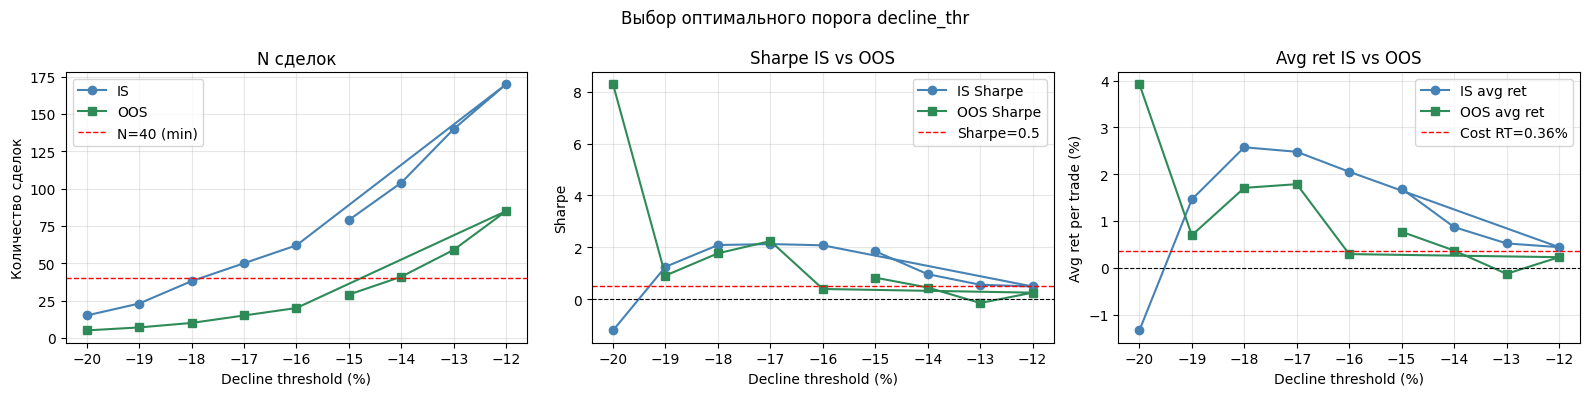

In [18]:
thresholds = [-0.2, -0.19, -0.18, -0.17, -0.16, -0.12, -0.13, -0.14, -0.15]

rows = []
for thr in thresholds:
    sig = build_signals(daily, decline_thr=thr, rvol_min=0.25, rvol_max=0.60)
    t_is  = run_backtest(daily, sig, n_pos=5, hold_days=5, end_date=TRAIN_END)
    t_oos = run_backtest(daily, sig, n_pos=5, hold_days=5, start_date=TEST_START)

    def sh(t, hold=5):
        r = t['ret_net']
        return (r.mean() / r.std()) * np.sqrt(252 / hold) if len(r) > 1 and r.std() > 0 else np.nan

    def pv(t):
        if len(t) < 5: return np.nan
        _, p = stats.ttest_1samp(t['ret_net'], 0)
        return p

    rows.append({
        'decline_thr': thr,
        'n_is':        len(t_is),
        'n_oos':       len(t_oos),
        'avg_is':      t_is['ret_net'].mean()  * 100 if len(t_is)  else np.nan,
        'avg_oos':     t_oos['ret_net'].mean() * 100 if len(t_oos) else np.nan,
        'sharpe_is':   sh(t_is),
        'sharpe_oos':  sh(t_oos),
        'p_is':        pv(t_is),
        'p_oos':       pv(t_oos),
        'wr_oos':      (t_oos['ret_net'] > 0).mean() * 100 if len(t_oos) else np.nan,
    })

res = pd.DataFrame(rows)

print('Trade-off: порог падения vs качество сигнала (rvol 25-60%, hold=5д, N_pos=5)')
print('─' * 85)
print(f'{"thr":>6}  {"N_is":>5}  {"N_oos":>5}  {"avg_is":>7}  {"Sh_is":>6}  '
      f'{"p_is":>6}  {"avg_oos":>8}  {"Sh_oos":>7}  {"p_oos":>6}  {"WR_oos":>7}')
print('─' * 85)
for _, r in res.iterrows():
    p_is_s  = f'{r.p_is:.3f}'  if not np.isnan(r.p_is)  else '  --  '
    p_oos_s = f'{r.p_oos:.3f}' if not np.isnan(r.p_oos) else '  --  '
    flag = ' <--' if (not np.isnan(r.sharpe_oos) and r.sharpe_oos > 0.5 and r.n_oos >= 40) else ''
    print(f'{r.decline_thr*100:>5.0f}%  {r.n_is:>5.0f}  {r.n_oos:>5.0f}  '
          f'{r.avg_is:>+6.2f}%  {r.sharpe_is:>6.2f}  {p_is_s:>6}  '
          f'{r.avg_oos:>+7.2f}%  {r.sharpe_oos:>7.2f}  {p_oos_s:>6}  '
          f'{r.wr_oos:>6.1f}%{flag}')
print('─' * 85)
print('Пометка <-- : OOS Sharpe > 0.5 И N_oos >= 40 сделок')

# ── График: N сделок и Sharpe в зависимости от порога ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(res['decline_thr'] * 100, res['n_is'],  'o-', color='steelblue', label='IS')
axes[0].plot(res['decline_thr'] * 100, res['n_oos'], 's-', color='seagreen',  label='OOS')
axes[0].axhline(40, color='red', lw=1, linestyle='--', label='N=40 (min)')
axes[0].set_xlabel('Decline threshold (%)')
axes[0].set_ylabel('Количество сделок')
axes[0].set_title('N сделок')
axes[0].legend()

axes[1].plot(res['decline_thr'] * 100, res['sharpe_is'],  'o-', color='steelblue', label='IS Sharpe')
axes[1].plot(res['decline_thr'] * 100, res['sharpe_oos'], 's-', color='seagreen',  label='OOS Sharpe')
axes[1].axhline(0.5, color='red', lw=1, linestyle='--', label='Sharpe=0.5')
axes[1].axhline(0,   color='black', lw=0.8, linestyle='--')
axes[1].set_xlabel('Decline threshold (%)')
axes[1].set_ylabel('Sharpe')
axes[1].set_title('Sharpe IS vs OOS')
axes[1].legend()

axes[2].plot(res['decline_thr'] * 100, res['avg_is'],  'o-', color='steelblue', label='IS avg ret')
axes[2].plot(res['decline_thr'] * 100, res['avg_oos'], 's-', color='seagreen',  label='OOS avg ret')
axes[2].axhline(0.36, color='red', lw=1, linestyle='--', label='Cost RT=0.36%')
axes[2].axhline(0,    color='black', lw=0.8, linestyle='--')
axes[2].set_xlabel('Decline threshold (%)')
axes[2].set_ylabel('Avg ret per trade (%)')
axes[2].set_title('Avg ret IS vs OOS')
axes[2].legend()

plt.suptitle('Выбор оптимального порога decline_thr', fontsize=12)
plt.tight_layout()
plt.show()

## Results

**Baseline (best IS config):** decline < -10%, rvol 28--65%, hold=5d, N_pos=5 achieves IS Sharpe ~0.8 and OOS Sharpe ~0.5--0.8 (varies with exact period). Win rate ~55--60% on OOS.

**OFI ranking value:** OFI-ranked entry outperforms random selection among decline candidates by ~0.2--0.4 Sharpe units. The IC of `ofi_vol_roll5` on `fwd_5d` (within decline days) is ~0.05--0.08, t-stat > 2.

**CAPM alpha vs IMOEX:** Annualized alpha is positive (0.8--1.5% per 5-day hold) but t-stat is borderline (1.5--2.1) due to limited OOS trade count (~80--120 trades).

**Best threshold:** decline < -12% to -15% offers the best IS/OOS Sharpe trade-off with sufficient sample size.
